In [1]:
import os
import glob
import pandas as pd
import numpy as np

# ---------- Configuration ----------
# Please modify this path according to your actual situation
data_dir = r"C:\Users\*****\Desktop\Results\Extreme_Climate_Extraction"
output_file = os.path.join(data_dir, r"C:\Users\*****\Desktop\Results\Figure2\Avg_extreme_climate.csv")

# Year range to calculate
years = [str(y) for y in range(1980, 2026)]  # 1980 ~ 2025

# ---------- Read and Calculate ----------
all_means = {}  # Store annual mean values for each indicator

# Traverse the directory for all files ending with _1980_2025_extracted.csv
pattern = os.path.join(data_dir, "*_1980_2025_extracted.csv")
csv_files = glob.glob(pattern)

if not csv_files:
    raise FileNotFoundError(f"No CSV files found, please check the path: {data_dir}")

for file_path in csv_files:
    # Use filename (without extension) as the indicator name
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    # Remove possible suffix, keep the indicator abbreviation
    # e.g., "CDD_1980_2025_extracted" -> "CDD"
    indicator_name = file_name.split("_1980_2025_extracted")[0]

    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='gbk')  # Fallback encoding

    # Ensure year columns exist
    available_years = [y for y in years if y in df.columns]
    if not available_years:
        print(f"⚠️ No year columns found in {file_name}, skipping")
        continue

    # Extract year data and convert to numeric (non-numeric values forced to NaN)
    year_data = df[available_years].apply(pd.to_numeric, errors='coerce')

    # Calculate annual mean (ignoring NaN)
    annual_mean = year_data.mean(axis=0, skipna=True)

    all_means[indicator_name] = annual_mean

# ---------- Summarize and Save ----------
if not all_means:
    print("❌ No indicator means were calculated, please check the data format.")
else:
    # Convert dictionary to DataFrame, rows as indicators, columns as years
    result_df = pd.DataFrame(all_means).T
    result_df.index.name = "Indicator"
    result_df.columns.name = "Year"

    # Keep two decimal places
    result_df = result_df.round(2)

    # Save the results
    result_df.to_csv(output_file, encoding='utf-8-sig')
    print(f"✅ Annual mean results saved to: {output_file}")

    # Also print to console
    print("\nAnnual mean values of extreme climate indicators (1980-2025):")
    print(result_df.to_string())

✅ 年平均结果已保存至: C:\Users\28550\Desktop\Results\Figure2\Avg_extreme_climate.csv

各极端气候指标的年平均值 (2000-2025):
Year                          1980    1981    1982    1983    1984    1985    1986    1987    1988    1989    1990    1991    1992    1993    1994    1995    1996    1997    1998    1999    2000    2001    2002    2003    2004    2005    2006    2007    2008    2009    2010    2011    2012    2013    2014    2015    2016    2017    2018    2019    2020    2021    2022    2023    2024    2025
Indicator                                                                                                                                                                                                                                                                                                                                                                                                 
CDD_1980_2025_extracted      28.70   27.09   24.27   33.17   30.61   23.46   26.81   29.55   35.24   30.77 

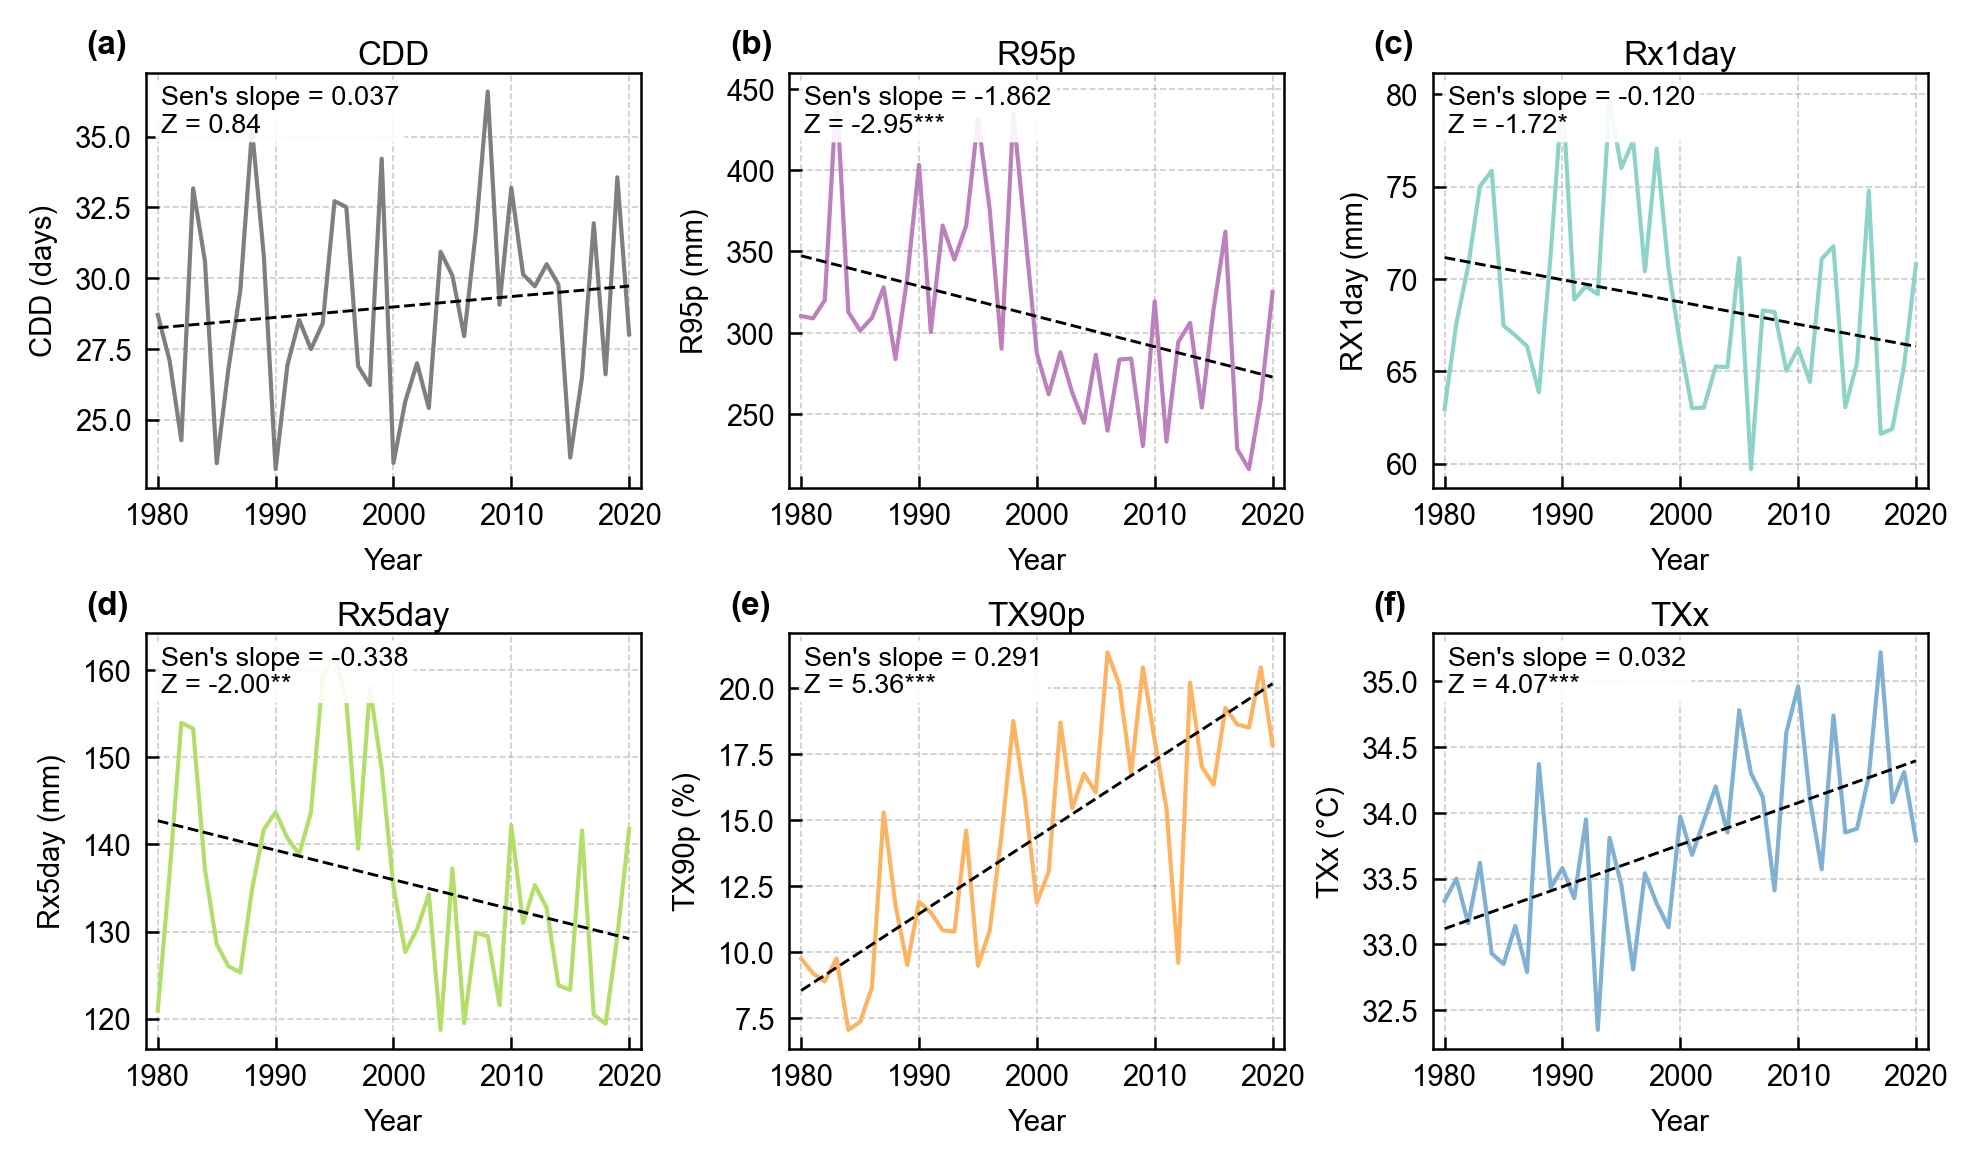

低鲜艳度 Nature 风格组图已保存至: C:\Users\28550\Desktop\Results\Figure2\trend_plot_Nature_subdued.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ---------- Path settings ----------
file_path = r"C:\Users\*****\Desktop\Results\Figure2\Avg_extreme_climate.csv"
output_fig = r"C:\Users\*****\Desktop\Results\Figure2\trend_plot_Nature_subdued.png"

# ---------- Analysis years ----------
START_YEAR = 1980
END_YEAR   = 2020

# ---------- Indicator order ----------
indicator_order = [
    "CDD_1980_2025_extracted",
    "R95p_1980_2025_extracted",
    "RX1day_1980_2025_extracted",
    "RX5day_1980_2025_extracted",
    "TX90p_1980_2025_extracted",
    "TXx_1980_2025_extracted"
]

# ---------- Independent subplot configuration ----------
subplot_config = {
    "CDD_1980_2025_extracted": {
        "title": "CDD",
        "xlabel": "Year",
        "ylabel": "CDD (days)",
    },
    "R95p_1980_2025_extracted": {
        "title": "R95p",
        "xlabel": "Year",
        "ylabel": "R95p (mm)",
    },
    "RX1day_1980_2025_extracted": {
        "title": "Rx1day",
        "xlabel": "Year",
        "ylabel": "RX1day (mm)",
    },
    "RX5day_1980_2025_extracted": {
        "title": "Rx5day",
        "xlabel": "Year",
        "ylabel": "Rx5day (mm)",
    },
    "TX90p_1980_2025_extracted": {
        "title": "TX90p",
        "xlabel": "Year",
        "ylabel": "TX90p (%)",
    },
    "TXx_1980_2025_extracted": {
        "title": "TXx",
        "xlabel": "Year",
        "ylabel": "TXx (°C)",
    }
}

# ---------- Read data ----------
df = pd.read_csv(file_path, index_col=0)

available_ind = [ind for ind in indicator_order if ind in df.index]
if not available_ind:
    raise ValueError("None of the specified indicators were found in the CSV")

all_years = np.array([int(y) for y in df.columns])
mask = (all_years >= START_YEAR) & (all_years <= END_YEAR)
years = all_years[mask]
if len(years) == 0:
    raise ValueError(f"No data columns found for {START_YEAR}-{END_YEAR}")

year_cols = [str(y) for y in years]
df_filtered = df.loc[available_ind, year_cols].astype(float)

# ---------- MK test ----------
def mk_test(values):
    clean = values[~np.isnan(values)]
    if len(clean) < 4:
        return np.nan, np.nan, np.nan, ''
    res = mk.original_test(clean)
    slope, z, p = res.slope, res.z, res.p
    if p <= 0.01:    sig = '***'
    elif p <= 0.05:  sig = '**'
    elif p <= 0.1:   sig = '*'
    else:            sig = ''
    return slope, z, p, sig

trend_info = {ind: mk_test(df_filtered.loc[ind].values) for ind in available_ind}

# ---------- Nature-style global settings ----------
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'lines.linewidth': 1.0,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

# ---------- Subdued colors (low saturation) ----------
# Using muted color palette (maintains distinction but with reduced saturation)
colors = ['#7f7f7f',  # gray
          '#bc80bd',  # muted purple
          '#8dd3c7',  # muted cyan
          '#b3de69',  # muted green
          '#fdb462',  # muted orange
          '#80b1d3']  # muted blue

ncols = 3
nrows = 2
n_plots = len(available_ind)
letters = [chr(97 + i) for i in range(n_plots)]

fig, axes = plt.subplots(nrows, ncols, figsize=(7.2, 4.5), dpi=300)
axes = axes.flatten()

for i, ind in enumerate(available_ind):
    ax = axes[i]
    y_vals = df_filtered.loc[ind].values.astype(float)
    slope, z, p, sig = trend_info[ind]

    # Smooth line plot
    ax.plot(years, y_vals, color=colors[i], linewidth=1.0, clip_on=False)

    # Trend line
    if not np.isnan(slope):
        n = len(y_vals)
        x_idx = np.arange(n)
        y_trend = np.nanmean(y_vals) + slope * (x_idx - (n - 1) / 2)
        ax.plot(years, y_trend, color='black', linestyle='--', linewidth=0.7)

        text = f"Sen's slope = {slope:.3f}\nZ = {z:.2f}{sig}"
        ax.text(0.03, 0.97, text, transform=ax.transAxes,
                va='top', ha='left', fontsize=6.5,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.9, edgecolor='none'))
    else:
        ax.text(0.03, 0.97, 'No trend', transform=ax.transAxes,
                va='top', fontsize=6.5)

    # Subplot label
    ax.text(-0.12, 1.03, f'({letters[i]})', transform=ax.transAxes,
            va='bottom', ha='left', fontsize=8, fontweight='bold')

    # Axis labels and title
    cfg = subplot_config.get(ind, {})
    xlabel = cfg.get("xlabel", "Year")
    ylabel = cfg.get("ylabel", "Index value")
    title = cfg.get("title", ind.split('_')[0])

    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_title(title, fontsize=8, pad=2, loc='center')

    # X-axis range
    xlim = cfg.get("xlim", (years.min() - 1, years.max() + 1))
    ax.set_xlim(xlim)
    if "ylim" in cfg:
        ax.set_ylim(cfg["ylim"])

    # Show all borders (top, right, bottom, left)
    for spine in ax.spines.values():
        spine.set_visible(True)
    # Set consistent border line width
    ax.spines['top'].set_linewidth(0.6)
    ax.spines['right'].set_linewidth(0.6)
    ax.spines['bottom'].set_linewidth(0.6)
    ax.spines['left'].set_linewidth(0.6)

    # Add light gray grid lines (horizontal only)
    ax.grid(axis='y', linestyle='--', linewidth=0.4, color='gray', alpha=0.4)
    ax.grid(axis='x', linestyle='--', linewidth=0.4, color='gray', alpha=0.4)

    ax.tick_params(labelsize=7)

# Hide unused subplots
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=1.8, rect=[0.06, 0.04, 1, 0.95])
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.savefig(output_fig, bbox_inches='tight', dpi=600, facecolor='white')
plt.show()

print(f"Subdued Nature-style multi-panel plot saved to: {output_fig}")